In [ ]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

In [ ]:
from google.colab import files
import pandas as pd
import io

# ==========================================
# STEP 1: UPLOAD THE FILE
# ==========================================
print("1. Click the button below to upload your CSV file:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# ==========================================
# STEP 2: SAMPLE 100 ROWS
# ==========================================
# If your file has fewer than 100 rows, it will gracefully just take what's available
sample_size = min(100, len(df))
df_sample = df.sample(n=sample_size, random_state=42)

print(f"\nSuccessfully sampled {sample_size} rows from your file.")

# ==========================================
# STEP 3: CHECK & MATCH WITH CHRONOS DATATYPES
# ==========================================
print("\n--- CHRONOS DATATYPE COMPLIANCE REPORT ---")

# Let's dynamically check each column in your file against standard Chronos expectations
for col in df.columns:
    current_dtype = df[col].dtype

    # Check if it's a valid Timestamp format
    is_timestamp = pd.api.types.is_datetime64_any_dtype(df[col]) or 'date' in col.lower() or 'time' in col.lower()

    # Check if it's a valid Target column (Numeric)
    is_numeric = pd.api.types.is_numeric_dtype(df[col])

    # Evaluate Chronos matching compatibility
    if is_timestamp:
        status = "✅ MATCHES Chronos requirement for: TIMESTAMP column"
        fix_note = "" if pd.api.types.is_datetime64_any_dtype(df[col]) else "⚠️ Note: Convert this column using `pd.to_datetime(df['" + col + "'])` before modeling."
    elif is_numeric:
        status = "✅ MATCHES Chronos requirement for: TARGET column (Values to forecast)"
        fix_note = ""
    else:
        status = "ℹ️ MATCHES Chronos requirement for: ITEM_ID or STATIC FEATURE column"
        fix_note = ""

    print(f"Column Name: '{col}'")
    print(f"  -> Detected Python Type: {current_dtype}")
    print(f"  -> Chronos Alignment  : {status}")
    if fix_note:
        print(f"  -> Recommended Action : {fix_note}")
    print("-" * 50)

# ==========================================
# STEP 4: DISPLAY THE 100 SAMPLE ROWS
# ==========================================
print("\n--- PREVIEW OF YOUR 100 SAMPLE ROWS ---")
df_sample



1. Click the button below to upload your CSV file:


Saving envirasense_data.csv to envirasense_data.csv

Successfully sampled 100 rows from your file.

--- CHRONOS DATATYPE COMPLIANCE REPORT ---
Column Name: 'timestamp'
  -> Detected Python Type: object
  -> Chronos Alignment  : ✅ MATCHES Chronos requirement for: TIMESTAMP column
  -> Recommended Action : ⚠️ Note: Convert this column using `pd.to_datetime(df['timestamp'])` before modeling.
--------------------------------------------------
Column Name: 'nodeId'
  -> Detected Python Type: object
  -> Chronos Alignment  : ℹ️ MATCHES Chronos requirement for: ITEM_ID or STATIC FEATURE column
--------------------------------------------------
Column Name: 'uptime_s'
  -> Detected Python Type: int64
  -> Chronos Alignment  : ✅ MATCHES Chronos requirement for: TIMESTAMP column
  -> Recommended Action : ⚠️ Note: Convert this column using `pd.to_datetime(df['uptime_s'])` before modeling.
--------------------------------------------------
Column Name: 'temperature'
  -> Detected Python Type: floa

,timestamp,nodeId,uptime_s,temperature,humidity,pressure,altitude_m,gas_kohm,voc,noise,bme680_status,noise_status
284,2026-09-17 10:51:28,NODE-001,2320,29.7,76,1007.7,47,50.6,459,98.3,online,online
358,2026-09-17 10:57:38,NODE-001,2690,29.9,76,1007.7,47,50.4,459,91.6,online,online
117,2026-09-17 10:37:33,NODE-001,1485,29.7,76,1007.7,46,49.0,460,92.1,online,online
423,2026-09-17 11:03:03,NODE-001,3015,29.9,76,1007.7,47,50.6,459,89.3,online,online
70,2026-09-17 10:33:38,NODE-001,1250,29.7,76,1007.7,46,48.4,461,88.3,online,online
...,...,...,...,...,...,...,...,...,...,...,...,...
84,2026-09-17 10:34:48,NODE-001,1320,29.7,76,1007.8,46,48.4,461,82.1,online,online
305,2026-09-17 10:53:13,NODE-001,2425,29.8,76,1007.7,47,50.8,458,86.9,online,online
351,2026-09-17 10:57:03,NODE-001,2655,29.8,76,1007.6,47,50.6,459,91.2,online,online
181,2026-09-17 10:42:53,NODE-001,1805,29.7,76,1007.7,46,49.8,459,83.0,online,online


In [ ]:
!pip install autogluon.timeseries



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of statsforecast to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.4/274.4 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.7/90.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.4/248.4 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 514.8/514.8 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.8/80.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.4/285.4 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 864.0

In [ ]:
import pandas as pd
from autogluon.timeseries import TimeSeriesDataFrame

# 1. Fix the timestamp column (converts text 'object' to real datetime)
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 2. Build the exact dataset format Chronos needs
# We map your columns to Chronos roles: item_id (nodeId), timestamp (timestamp), and your targets
chronos_data = TimeSeriesDataFrame.from_data_frame(
    df,
    id_column="nodeId",
    timestamp_column="timestamp"
)

# 3. Print verification to prove it works perfectly now
print("✨ SUCCESS: Your data is now fully matched with Chronos requirements!")
print("\n--- NEW CHRONOS DATA TYPE CHECK ---")
print(chronos_data.info())

# Show a clean preview of the final Chronos dataset
chronos_data.head()

✨ SUCCESS: Your data is now fully matched with Chronos requirements!

--- NEW CHRONOS DATA TYPE CHECK ---
<class 'autogluon.timeseries.dataset.ts_dataframe.TimeSeriesDataFrame'>
MultiIndex: 446 entries, ('NODE-001', Timestamp('2026-09-17 10:27:48')) to ('NODE-001', Timestamp('2026-09-17 11:04:53'))
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   uptime_s       446 non-null    int64  
 1   temperature    446 non-null    float64
 2   humidity       446 non-null    int64  
 3   pressure       446 non-null    float64
 4   altitude_m     446 non-null    int64  
 5   gas_kohm       446 non-null    float64
 6   voc            446 non-null    int64  
 7   noise          446 non-null    float64
 8   bme680_status  446 non-null    object 
 9   noise_status   446 non-null    object 
dtypes: float64(4), int64(4), object(2)
memory usage: 56.0+ KB
None


uptime_s  temperature  humidity  pressure  \
item_id  timestamp                                                        
NODE-001 2026-09-17 10:27:48       900         29.7        76    1007.8   
         2026-09-17 10:27:53       905         29.7        76    1007.8   
         2026-09-17 10:27:58       910         29.7        76    1007.8   
         2026-09-17 10:28:03       915         29.7        76    1007.8   
         2026-09-17 10:28:08       920         29.7        76    1007.8   

                              altitude_m  gas_kohm  voc  noise bme680_status  \
item_id  timestamp                                                             
NODE-001 2026-09-17 10:27:48          45      47.1  462   77.4        online   
         2026-09-17 10:27:53          45      46.9  462   89.8        online   
         2026-09-17 10:27:58          45      46.9  462   81.1        online   
         2026-09-17 10:28:03          45      47.1  462   92.7        online   
         2026-09-17 10:28:08          45      46.9  462   83.5        online   

                             noise_status  
item_id  timestamp                         
NODE-001 2026-09-17 10:27:48       online  
         2026-09-17 10:27:53       online  
         2026-09-17 10:27:58       online  
         2026-09-17 10:28:03       online  
         2026-09-17 10:28:08       online

Beginning AutoGluon training... Time limit = 450s
AutoGluon will save models to '/content/AutogluonModels/ag-20260924_031725'



🧠 Training high-accuracy model for: TEMPERATURE...


=================== System Info ===================
AutoGluon Version:  1.6.3
Python Version:     3.13.15
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.11.0+cpu
CUDA Version:       CUDA is not available
GPU Memory:         
Total GPU Memory:   Free: 0.00 GB, Allocated: 0.00 GB, Total: 0.00 GB
GPU Count:          0
Memory Avail:       11.35 GB / 12.67 GB (89.6%)
Disk Space Avail:   86.53 GB / 107.72 GB (80.3%)
Setting presets to: best_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': MASE,
 'hyperparameters': 'default',
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 24,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'refit_every_n_windows': 'auto',
 'refit_full': False,
 'skip_model_selection': False,
 'target': 'temperature',
 'time_limit': 450,
 'verbosity': 2}

Inferred time series fr

config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  478MB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.7MB            

model.safetensors: downloading bytes:           |  0.00B            

	-30.6630      = Validation score (-MASE)
	2.74    s     = Training runtime
	0.10    s     = Validation (prediction) runtime
Training timeseries model TemporalFusionTransformer. Training for up to 135.4s of the 406.1s of remaining time.
	-29.5865      = Validation score (-MASE)
	130.59  s     = Training runtime
	0.03    s     = Validation (prediction) runtime
Training timeseries model DeepAR. Training for up to 137.7s of the 275.5s of remaining time.
	-30.0809      = Validation score (-MASE)
	124.13  s     = Training runtime
	0.14    s     = Validation (prediction) runtime
Fitting 1 ensemble(s), in 1 layers.
Training ensemble model WeightedEnsemble. Training for up to 151.1s.
	Ensemble weights: {'RecursiveTabular': 1.0}
	-29.4630      = Validation score (-MASE)
	0.44    s     = Training runtime
	0.16    s     = Validation (prediction) runtime
Training complete. Models trained: ['SeasonalNaive', 'RecursiveTabular', 'DirectTabular', 'DynamicOptimizedTheta', 'Chronos2', 'AutoETS', 'Toto2'

🔮 Generating 2-minute future predictions for temperature...


<Figure size 1200x400 with 0 Axes>

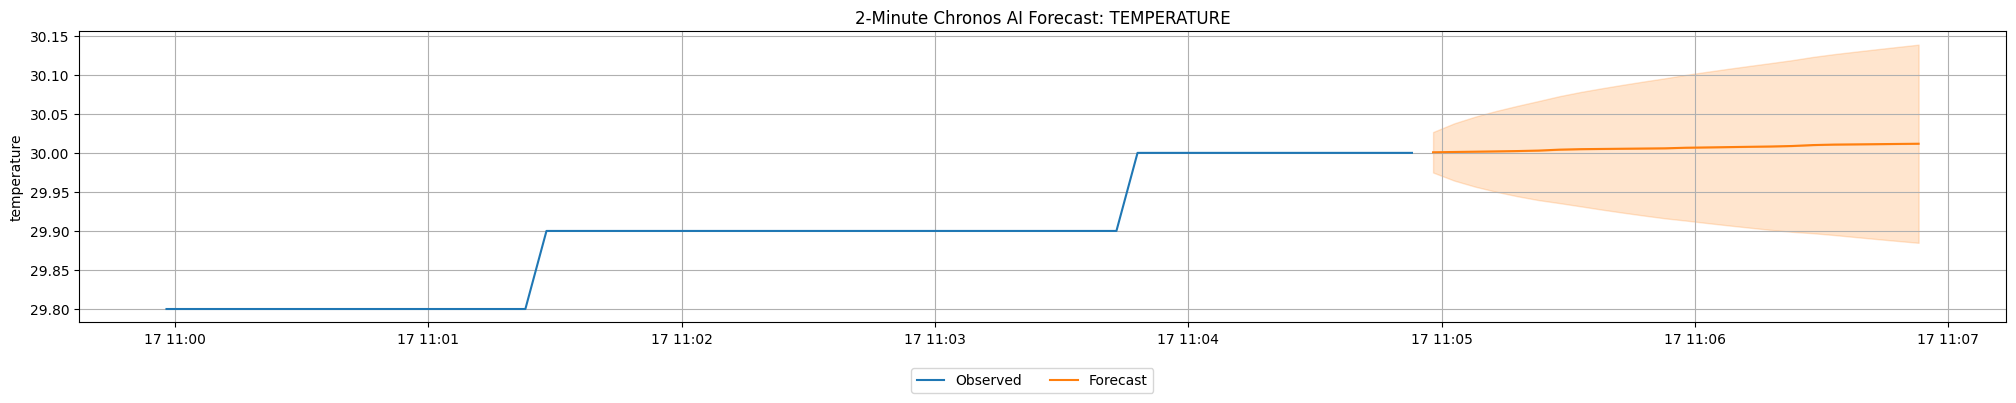

No path specified. Models will be saved in: "AutogluonModels/ag-20260924_032225"
Beginning AutoGluon training... Time limit = 450s
AutoGluon will save models to '/content/AutogluonModels/ag-20260924_032225'
=================== System Info ===================
AutoGluon Version:  1.6.3
Python Version:     3.13.15
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.11.0+cpu
CUDA Version:       CUDA is not available
GPU Memory:         
Total GPU Memory:   Free: 0.00 GB, Allocated: 0.00 GB, Total: 0.00 GB
GPU Count:          0
Memory Avail:       10.51 GB / 12.67 GB (83.0%)
Disk Space Avail:   85.83 GB / 107.72 GB (79.7%)
Setting presets to: best_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': MASE,
 'hyperparameters': 'default',
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 24,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 


🧠 Training high-accuracy model for: VOC...


	-6.9939       = Validation score (-MASE)
	0.84    s     = Training runtime
	0.15    s     = Validation (prediction) runtime
Training timeseries model DirectTabular. Training for up to 49.9s of the 448.9s of remaining time.
	-0.4785       = Validation score (-MASE)
	0.82    s     = Training runtime
	0.07    s     = Validation (prediction) runtime
Training timeseries model DynamicOptimizedTheta. Training for up to 56.0s of the 448.0s of remaining time.
	-0.7680       = Validation score (-MASE)
	0.02    s     = Training runtime
	0.02    s     = Validation (prediction) runtime
Training timeseries model Chronos2. Training for up to 64.0s of the 447.9s of remaining time.
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resol

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

	-0.0341       = Validation score (-MASE)
	0.78    s     = Training runtime
	1.26    s     = Validation (prediction) runtime
Training timeseries model Chronos2SmallFineTuned. Training for up to 74.3s of the 445.9s of remaining time.
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2-small/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2-small/ddec01313e50b6bc58ebaa92ede81bc24a3d9f9a/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/autogluon/chronos-2-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/autogluon/chronos-2-small/ddec01313e50b6bc58ebaa92ede81bc24a3d9f9a/config.json "HTTP/1.1 200 OK"
INFO

Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]

Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/autogluon/timeseries/trainer/trainer.py", line 362, in _train_and_save
    model.fit(
    ~~~~~~~~~^
        train_data=train_data,
        ^^^^^^^^^^^^^^^^^^^^^^
    ...<4 lines>...
        refit_every_n_windows=self.refit_every_n_windows,
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/autogluon/timeseries/models/abstract/abstract_timeseries_model.py", line 580, in fit
    self._fit(
    ~~~~~~~~~^
        train_data=train_data,
        ^^^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
        **(self._get_system_resources() | kwargs),
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/autogluon/timeseries/models/multi_window/multi_window_model.py", line 147, in _fit
    model.fit(
    ~~~~~~~~~^
        train_data=train_fold,
        ^^^^^^^^^^^^^^^^^^^^^^
    ...<3 lines>...
    

🔮 Generating 2-minute future predictions for voc...


<Figure size 1200x400 with 0 Axes>

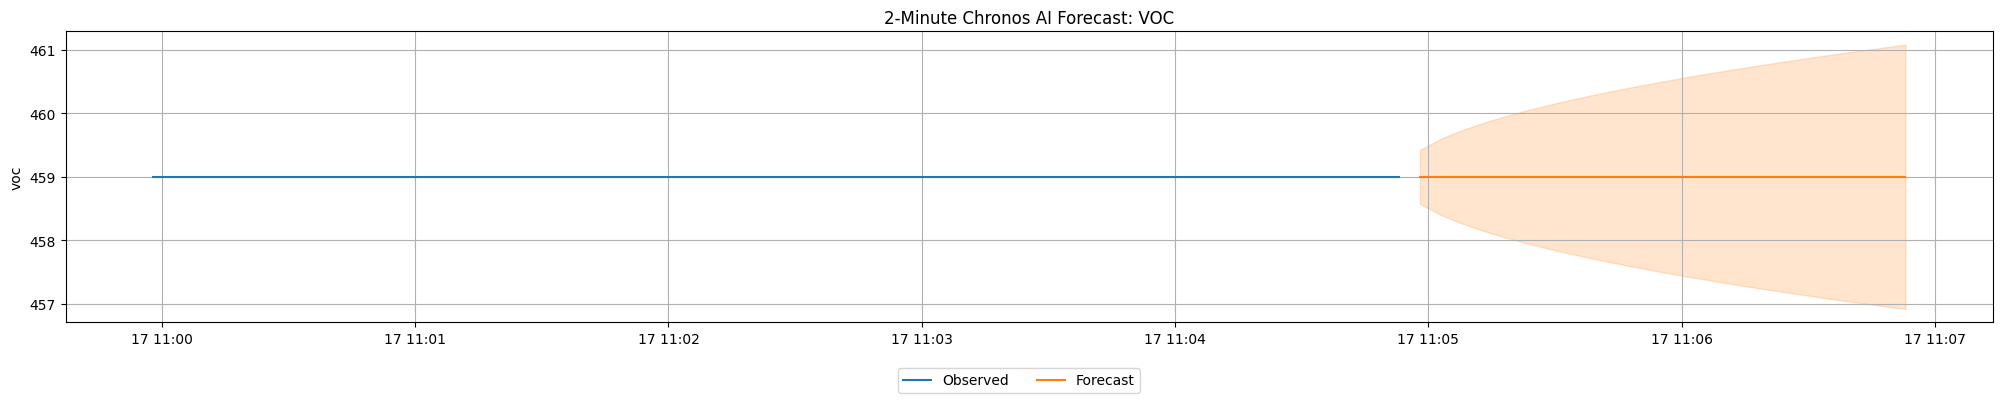


💾 Compiling results into your download file...
✅ Success! File 'future_2min_sensor_forecasts.csv' is ready.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from autogluon.timeseries import TimeSeriesPredictor

# ==========================================
# CONFIGURATION: 2-MINUTE EXTENSION & VARIABLES
# ==========================================
FORECAST_STEPS = 24  # 24 steps * 5s = 2 minutes
TARGET_COLUMNS = ["temperature", "voc"]
all_forecasts = []

plt.close('all')

# ==========================================
# LOOP THROUGH BOTH TARGETS WITH CORRECTED PRESETS
# ==========================================
for target in TARGET_COLUMNS:
    print(f"\n🧠 Training high-accuracy model for: {target.upper()}...")

    predictor = TimeSeriesPredictor(
        prediction_length=FORECAST_STEPS,
        target=target,
        eval_metric="MASE"
    )

    # FIXED: Swapped preset to 'best_quality' and set window buffers for smaller datasets
    predictor.fit(
        chronos_data,
        presets="best_quality",   # Uses AutoGluon's maximum accuracy tuning combination
        num_val_windows=1,         # Keeps validation footprint safe for short timelines
        time_limit=450
    )

    print(f"🔮 Generating 2-minute future predictions for {target}...")
    predictions = predictor.predict(chronos_data)

    # Store predictions
    target_pred = predictions[['mean']].copy()
    target_pred.columns = [f"{target}_predicted_mean"]
    all_forecasts.append(target_pred)

    # Generate Visual Graph
    plt.figure(figsize=(12, 4))
    predictor.plot(
        data=chronos_data,
        predictions=predictions,
        item_ids=["NODE-001"],
        max_history_length=60
    )
    plt.title(f"2-Minute Chronos AI Forecast: {target.upper()}")
    plt.grid(True)
    plt.show()

# ==========================================
# COMBINE AND DOWNLOAD THE HIGH-ACCURACY DATA
# ==========================================
print("\n💾 Compiling results into your download file...")
final_csv_dataframe = pd.concat(all_forecasts, axis=1).reset_index()

output_filename = "future_2min_sensor_forecasts.csv"
final_csv_dataframe.to_csv(output_filename, index=False)

print(f"✅ Success! File '{output_filename}' is ready.")
files.download(output_filename)




